# BTC statistical arbitrage: two eigenportfolios

This notebook follows the model in order: **(1) eigenportfolios, (2) BTC factor regression, (3) residual and cumulative residual, (4) AR(1)/OU fit, and (5) a walk-forward trading backtest**. Exactly the first two eigenportfolios are used throughout.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statarb import (Market, correlation_matrix, decompose, eigen_portfolios,
                     fit_residuals, residual_ar1, rolling_ar1,
                     prepare_residual_path, search_ar_windows, search_entry_exit,
                     backtest_residual_path)

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

ASSET = 'BTC'
WHEN = '2021-06-01 12:00'
WINDOW = 240
N_FACTORS = 2
AR_WINDOW = 20
DEVELOPMENT_SHARE = 0.80
AR_WINDOW_GRID = [12, 18, 24, 36, 48, 72, 96, 120, 168, 240]  # hours
ENTRY_GRID = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0]
EXIT_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
ENTRY, EXIT, COST_BPS = 2.0, 0.5, 5.0

market = Market.load('data')
print(f'Data: {market.returns.index[0]} through {market.returns.index[-1]}')

Data: 2021-02-19 05:00:00+00:00 through 2022-09-26 03:00:00+00:00


## 1. Correlation eigenstructure and the two eigenportfolios

The eigenvectors of the top-40 return correlation matrix define the factor portfolios. We deliberately retain only PC1 and PC2.

PC1 + PC2 explain 77.30% of cross-sectional variance.


,eigenvalue,explained,cumulative
component,,,
0,30.0492,0.7512,0.7512
1,0.8721,0.0218,0.7730
2,0.7143,0.0179,0.7909
3,0.6959,0.0174,0.8083
4,0.6290,0.0157,0.8240
5,0.5575,0.0139,0.8379
6,0.4810,0.0120,0.8500
7,0.4642,0.0116,0.8616
8,0.4468,0.0112,0.8727


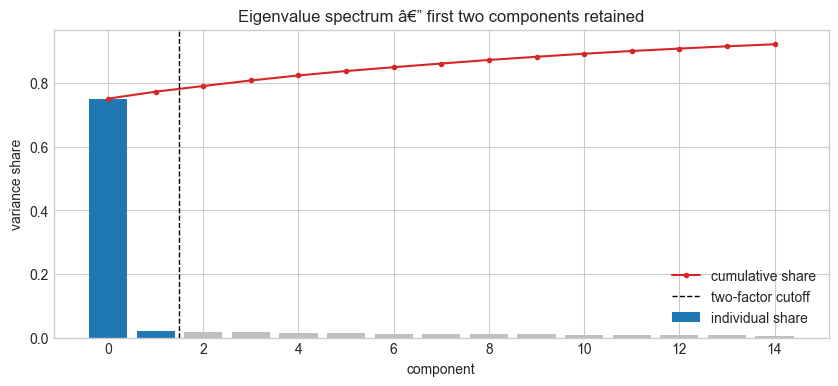

In [3]:
corr = correlation_matrix(market, WHEN, window=WINDOW)
eig = decompose(corr)
portfolios = eigen_portfolios(market, WHEN, window=WINDOW, components=range(N_FACTORS))

summary = eig.summary()
print(f'PC1 + PC2 explain {summary.loc[1, "cumulative"]:.2%} of cross-sectional variance.')
display(summary.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
top = summary.head(15)
colors = ['tab:blue' if i < N_FACTORS else '0.75' for i in top.index]
ax.bar(top.index, top['explained'], color=colors, label='individual share')
ax.plot(top.index, top['cumulative'], color='tab:red', marker='o', ms=3, label='cumulative share')
ax.axvline(1.5, color='black', ls='--', lw=1, label='two-factor cutoff')
ax.set(title='Eigenvalue spectrum, first two components retained', xlabel='component', ylabel='variance share')
ax.legend(); plt.show()

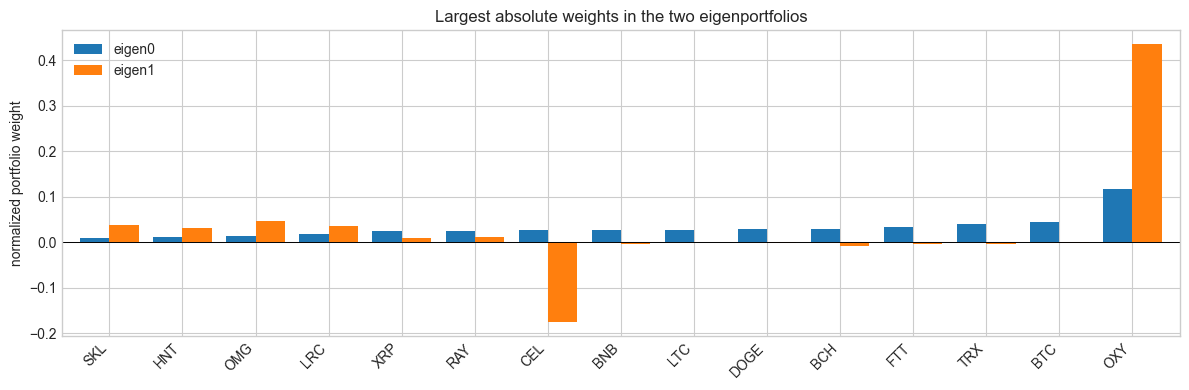

BTC weights: PC1=0.0452, PC2=-0.0024


In [4]:
weights = pd.concat([pf.weights.rename(pf.name) for pf in portfolios], axis=1)
important = weights.abs().max(axis=1).nlargest(15).index
ax = weights.loc[important].sort_values('eigen0').plot.bar(figsize=(12, 4), width=0.8)
ax.axhline(0, color='black', lw=0.7)
ax.set(title='Largest absolute weights in the two eigenportfolios', ylabel='normalized portfolio weight', xlabel='')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print(f'BTC weights: PC1={weights.loc[ASSET, "eigen0"]:.4f}, PC2={weights.loc[ASSET, "eigen1"]:.4f}')

## 2. BTC regression on PC1 and PC2

We fit standardized BTC returns as `BTC = alpha + beta_1 PC1 + beta_2 PC2 + residual`.

,BTC regression
alpha,0.0000
beta_PC1,0.9220
beta_PC2,-0.0067
R_squared,0.8501


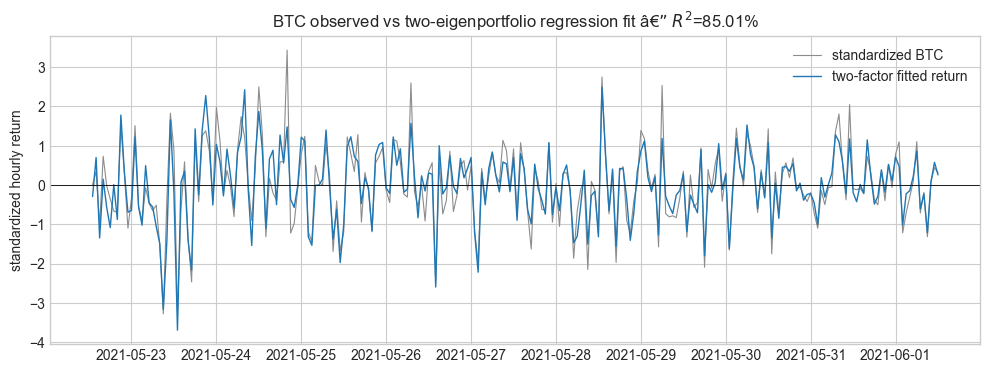

In [5]:
model = fit_residuals(market, when=WHEN, window=WINDOW, n_factors=N_FACTORS, include=[ASSET])
regression = pd.Series({
    'alpha': model.alphas[ASSET],
    'beta_PC1': model.betas.loc[ASSET, 'eigen0'],
    'beta_PC2': model.betas.loc[ASSET, 'eigen1'],
    'R_squared': model.r_squared[ASSET],
}, name='BTC regression')
display(regression.to_frame())

observed = model.standardized[ASSET]
fitted = observed - model.residuals[ASSET]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(observed.index, observed, lw=0.8, color='0.55', label='standardized BTC')
ax.plot(fitted.index, fitted, lw=1.0, color='tab:blue', label='two-factor fitted return')
ax.axhline(0, color='black', lw=0.6)
ax.set(title=f'BTC observed vs two-eigenportfolio regression fit, $R^2$={regression.R_squared:.2%}', ylabel='standardized hourly return')
ax.legend(); plt.show()

## 3. Residual and cumulative residual

The residual is BTC's return unexplained by PC1 and PC2. Its cumulative sum, `X(t)`, is the process modeled as mean reverting.

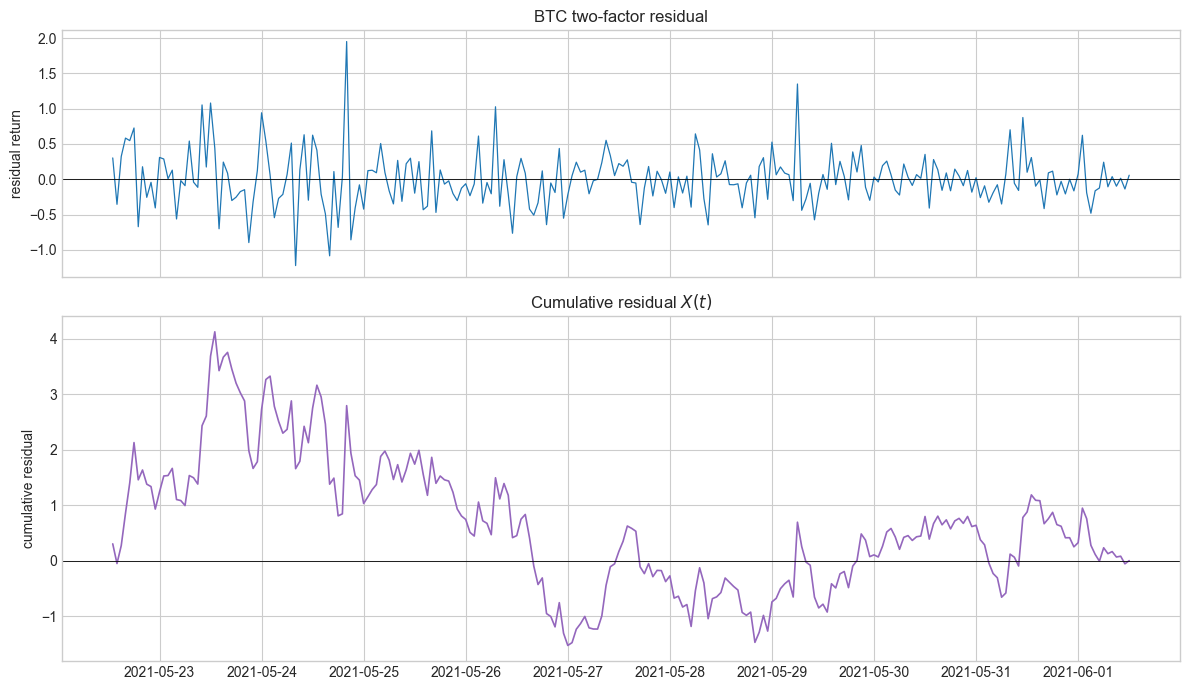

,residual,cumulative_residual
startTime,,
2021-06-01 03:00:00+00:00,-0.4809,0.2762
2021-06-01 04:00:00+00:00,-0.1632,0.1130
2021-06-01 05:00:00+00:00,-0.1232,-0.0102
2021-06-01 06:00:00+00:00,0.2420,0.2318
2021-06-01 07:00:00+00:00,-0.1064,0.1254
2021-06-01 08:00:00+00:00,0.0379,0.1633
2021-06-01 09:00:00+00:00,-0.0981,0.0652
2021-06-01 10:00:00+00:00,0.0146,0.0798
2021-06-01 11:00:00+00:00,-0.1375,-0.0577


In [6]:
residual = model.residuals[ASSET]
X = residual.cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [1, 1.4]})
ax1.plot(residual.index, residual, color='tab:blue', lw=0.9)
ax1.axhline(0, color='black', lw=0.6)
ax1.set(title='BTC two-factor residual', ylabel='residual return')
ax2.plot(X.index, X, color='tab:purple', lw=1.2)
ax2.axhline(0, color='black', lw=0.6)
ax2.set(title='Cumulative residual $X(t)$', ylabel='cumulative residual')
plt.tight_layout(); plt.show()
display(pd.DataFrame({'residual': residual, 'cumulative_residual': X}).tail(10))

## 4. AR(1) / OU mean-reversion fit

The last 20 cumulative-residual observations are fitted as `X[t+1] = a + b X[t] + innovation`. The equilibrium is `m = a/(1-b)`, and the s-score measures the current distance from equilibrium.

,estimate
a,0.0609
b,0.7263
m,0.2224
kappa,"2,801.7687"
tau_days,0.1303
innovation_std,0.2080
sigma_eq,0.3027
s_score,-0.7347
nobs,20
stationary,True


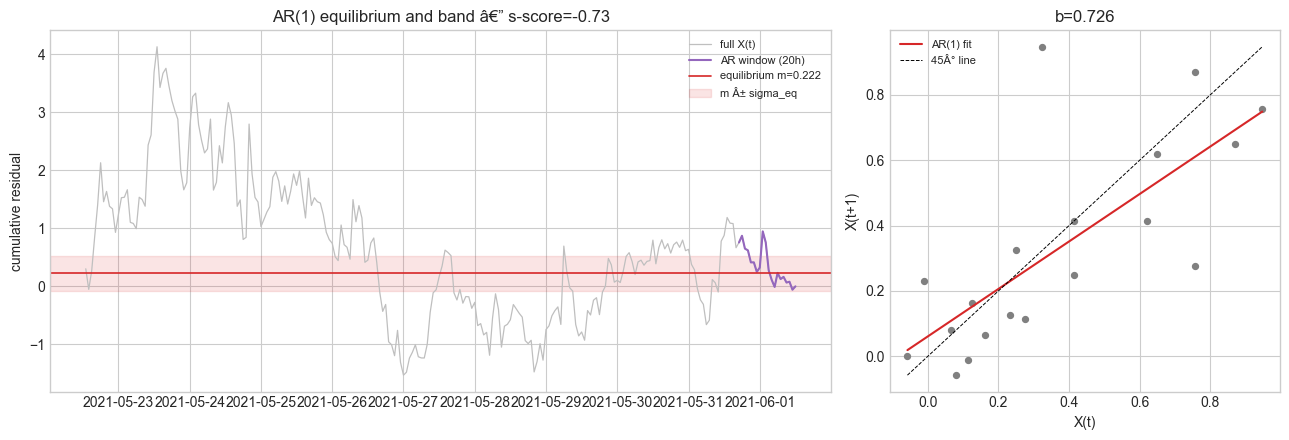

In [7]:
ar = residual_ar1(model, ASSET, window=AR_WINDOW)
display(ar.to_series().to_frame('estimate'))

Xf = X.tail(AR_WINDOW)
x0, x1 = Xf.iloc[:-1], Xf.iloc[1:]
grid = np.linspace(x0.min(), x0.max(), 100)
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2, 1]})
left.plot(X.index, X, color='0.75', lw=0.9, label='full X(t)')
left.plot(Xf.index, Xf, color='tab:purple', lw=1.5, label=f'AR window ({AR_WINDOW}h)')
left.axhline(ar.mean, color='tab:red', lw=1.2, label=f'equilibrium m={ar.mean:.3f}')
left.axhspan(ar.mean-ar.sigma_eq, ar.mean+ar.sigma_eq, color='tab:red', alpha=0.12, label='m +/- sigma_eq')
left.set(title=f'AR(1) equilibrium and band, s-score={ar.s_score:.2f}', ylabel='cumulative residual')
left.legend(fontsize=8)
right.scatter(x0, x1, s=18, color='0.5')
right.plot(grid, ar.intercept + ar.slope*grid, color='tab:red', label='AR(1) fit')
right.plot(grid, grid, color='black', ls='--', lw=0.7, label='45 degree line')
right.set(xlabel='X(t)', ylabel='X(t+1)', title=f'b={ar.slope:.3f}')
right.legend(fontsize=8); plt.tight_layout(); plt.show()

### 4b. Moving AR(1) equilibrium m(t)

A single terminal fit hides changes in equilibrium. Here the same `AR_WINDOW`-hour AR(1) is re-estimated at every hour. The red curve is the moving equilibrium `m(t) = a(t)/(1-b(t))`; the band and s-score use that hour's fitted equilibrium volatility. Non-stationary windows are left blank.

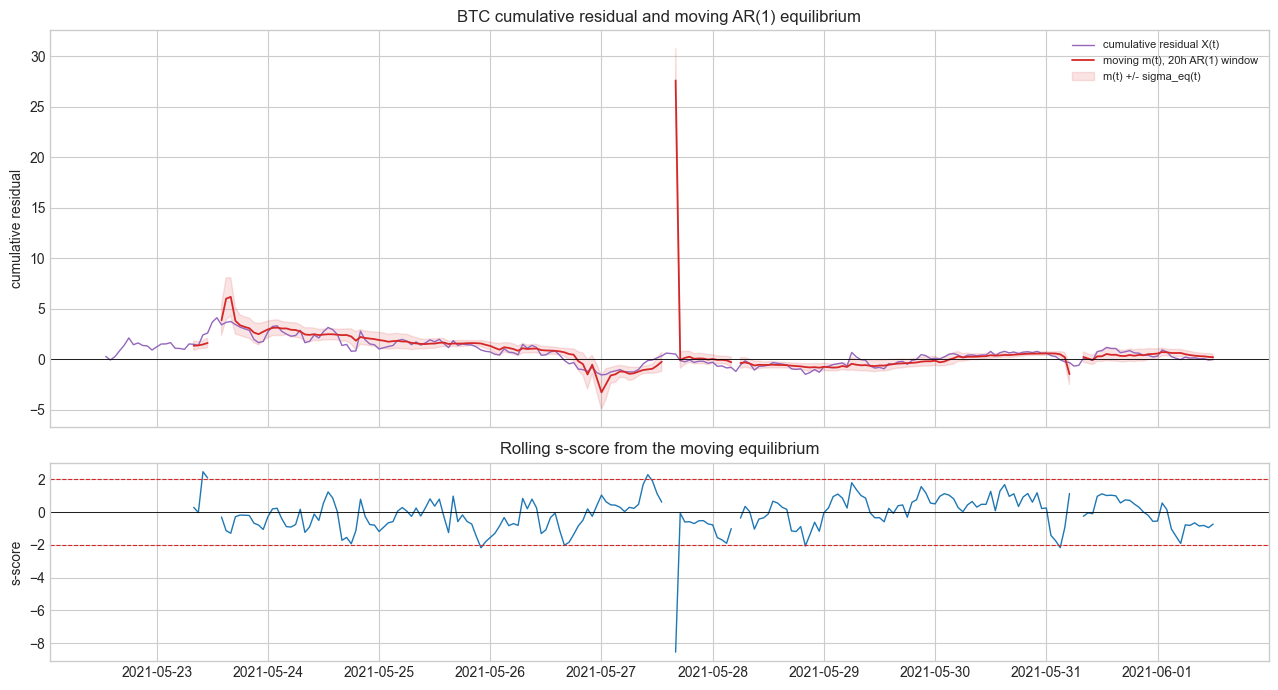

,b,m,sigma_eq,tau_days,s_score,stationary
startTime,,,,,,
2021-06-01 03:00:00+00:00,0.5872,0.6392,0.3526,0.0783,-1.0293,True
2021-06-01 04:00:00+00:00,0.5748,0.6337,0.3516,0.0753,-1.4807,True
2021-06-01 05:00:00+00:00,0.5525,0.6402,0.3401,0.0702,-1.9124,True
2021-06-01 06:00:00+00:00,0.7543,0.5175,0.3671,0.1478,-0.7782,True
2021-06-01 07:00:00+00:00,0.7710,0.4328,0.3781,0.1602,-0.8132,True
2021-06-01 08:00:00+00:00,0.7234,0.3715,0.3167,0.1287,-0.6575,True
2021-06-01 09:00:00+00:00,0.7084,0.3277,0.3104,0.1208,-0.8456,True
2021-06-01 10:00:00+00:00,0.6508,0.3076,0.2796,0.0970,-0.8147,True
2021-06-01 11:00:00+00:00,0.7547,0.2506,0.3252,0.1480,-0.9480,True


In [8]:
roll = rolling_ar1(X, window=AR_WINDOW)
stationary = roll['stationary'].astype(bool)
moving_m = roll['m'].astype(float).where(stationary)
moving_sigma = roll['sigma_eq'].astype(float).where(stationary)
moving_s = roll['s_score'].astype(float).where(stationary)
lower = moving_m - moving_sigma
upper = moving_m + moving_sigma

fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
top.plot(X.index, X, color='tab:purple', lw=1.0, label='cumulative residual X(t)')
top.plot(moving_m.index, moving_m, color='tab:red', lw=1.3, label=f'moving m(t), {AR_WINDOW}h AR(1) window')
top.fill_between(moving_m.index, lower, upper, color='tab:red', alpha=0.13, label='m(t) +/- sigma_eq(t)')
top.axhline(0, color='black', lw=0.6)
top.set(title='BTC cumulative residual and moving AR(1) equilibrium', ylabel='cumulative residual')
top.legend(fontsize=8)

bottom.plot(moving_s.index, moving_s, color='tab:blue', lw=1.0)
bottom.axhline(0, color='black', lw=0.6)
for level in (-ENTRY, ENTRY): bottom.axhline(level, color='tab:red', ls='--', lw=0.8)
bottom.set(title='Rolling s-score from the moving equilibrium', ylabel='s-score')
plt.tight_layout(); plt.show()

display(roll[['b', 'm', 'sigma_eq', 'tau_days', 's_score', 'stationary']].tail(10))

## 5. Full-dataset 80/20 AR-window search and OOS backtest

After the initial 240-hour formation warmup, every usable observation in the dataset is included. The first 80% is the development segment used to select the rolling AR window by net Sharpe; the last 20% is untouched final OOS data. Every residual at hour `t` uses a two-factor regression estimated only through `t-1`, and the rolling-AR signal at `t` is executed at `t+1`. Entry is at absolute s-score 2, exit at 0.5, with 5 bps factor-hedge turnover costs.

In [9]:
PATH_CACHE = Path('data/btc_two_factor_residual_path.pkl')
if PATH_CACHE.exists():
    path = pd.read_pickle(PATH_CACHE)
    print(f'Loaded cached residual path: {PATH_CACHE}')
else:
    path = prepare_residual_path(
        market, ASSET, estimation_window=WINDOW, n_factors=N_FACTORS, variance=None,
    )
    pd.to_pickle(path, PATH_CACHE)
    print(f'Cached residual path: {PATH_CACHE}')
split = int(len(path.frame) * DEVELOPMENT_SHARE)
development_end = path.frame.index[split - 1]
oos_start = path.frame.index[split]
oos_end = path.frame.index[-1]
print(f'Usable walk-forward bars: {len(path.frame):,}')
print(f'Development 80%: {path.frame.index[0]} through {development_end} ({split:,} bars)')
print(f'Final OOS 20%:   {oos_start} through {oos_end} ({len(path.frame)-split:,} bars)')

window_search = search_ar_windows(
    path, AR_WINDOW_GRID, development_end=development_end,
    entry=ENTRY, exit=EXIT, cost_bps=COST_BPS, min_trades=10,
)
SELECTED_AR_WINDOW = window_search.attrs['selected_window']
print(f'Selected rolling AR window: {SELECTED_AR_WINDOW} hours')
display(window_search.sort_values('objective', ascending=False))

ax = window_search['objective'].plot(marker='o', figsize=(10, 4), color='tab:blue')
ax.axvline(SELECTED_AR_WINDOW, color='tab:red', ls='--', label=f'selected: {SELECTED_AR_WINDOW}h')
ax.set(title='Empirical AR-window search on the first 80% only', xlabel='rolling AR window (hours)', ylabel='development net Sharpe')
ax.legend(); plt.show()

threshold_search = search_entry_exit(
    path, SELECTED_AR_WINDOW, ENTRY_GRID, EXIT_GRID,
    development_end=development_end, cost_bps=COST_BPS, min_trades=10,
)
SELECTED_ENTRY = threshold_search.attrs['selected_entry']
SELECTED_EXIT = threshold_search.attrs['selected_exit']
print(f'Selected thresholds: entry={SELECTED_ENTRY}, exit={SELECTED_EXIT}')
display(threshold_search.sort_values('objective', ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['sharpe', 'total_return'], ['Development net Sharpe', 'Development total return']):
    grid = threshold_search[metric].unstack('exit')
    image = ax.imshow(grid.to_numpy(dtype=float), aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(grid.columns)), [f'{x:g}' for x in grid.columns])
    ax.set_yticks(range(len(grid.index)), [f'{x:g}' for x in grid.index])
    ax.set(xlabel='exit threshold', ylabel='entry threshold', title=title)
    for row in range(len(grid.index)):
        for col in range(len(grid.columns)):
            value = grid.iloc[row, col]
            if np.isfinite(value): ax.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=7)
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

bt = backtest_residual_path(
    path, SELECTED_AR_WINDOW, start=oos_start, end=oos_end,
    entry=SELECTED_ENTRY, exit=SELECTED_EXIT, cost_bps=COST_BPS,
)
display(bt.metrics.to_frame('OOS value'))
display(bt.trades)

NotImplementedError: (<StringDtype(storage='python', na_value=nan)>, array(['signal_time', 'residual', 'n_factors', 'unit_spread_return',
       'rebalance_turnover', 'token_return'], dtype=object))

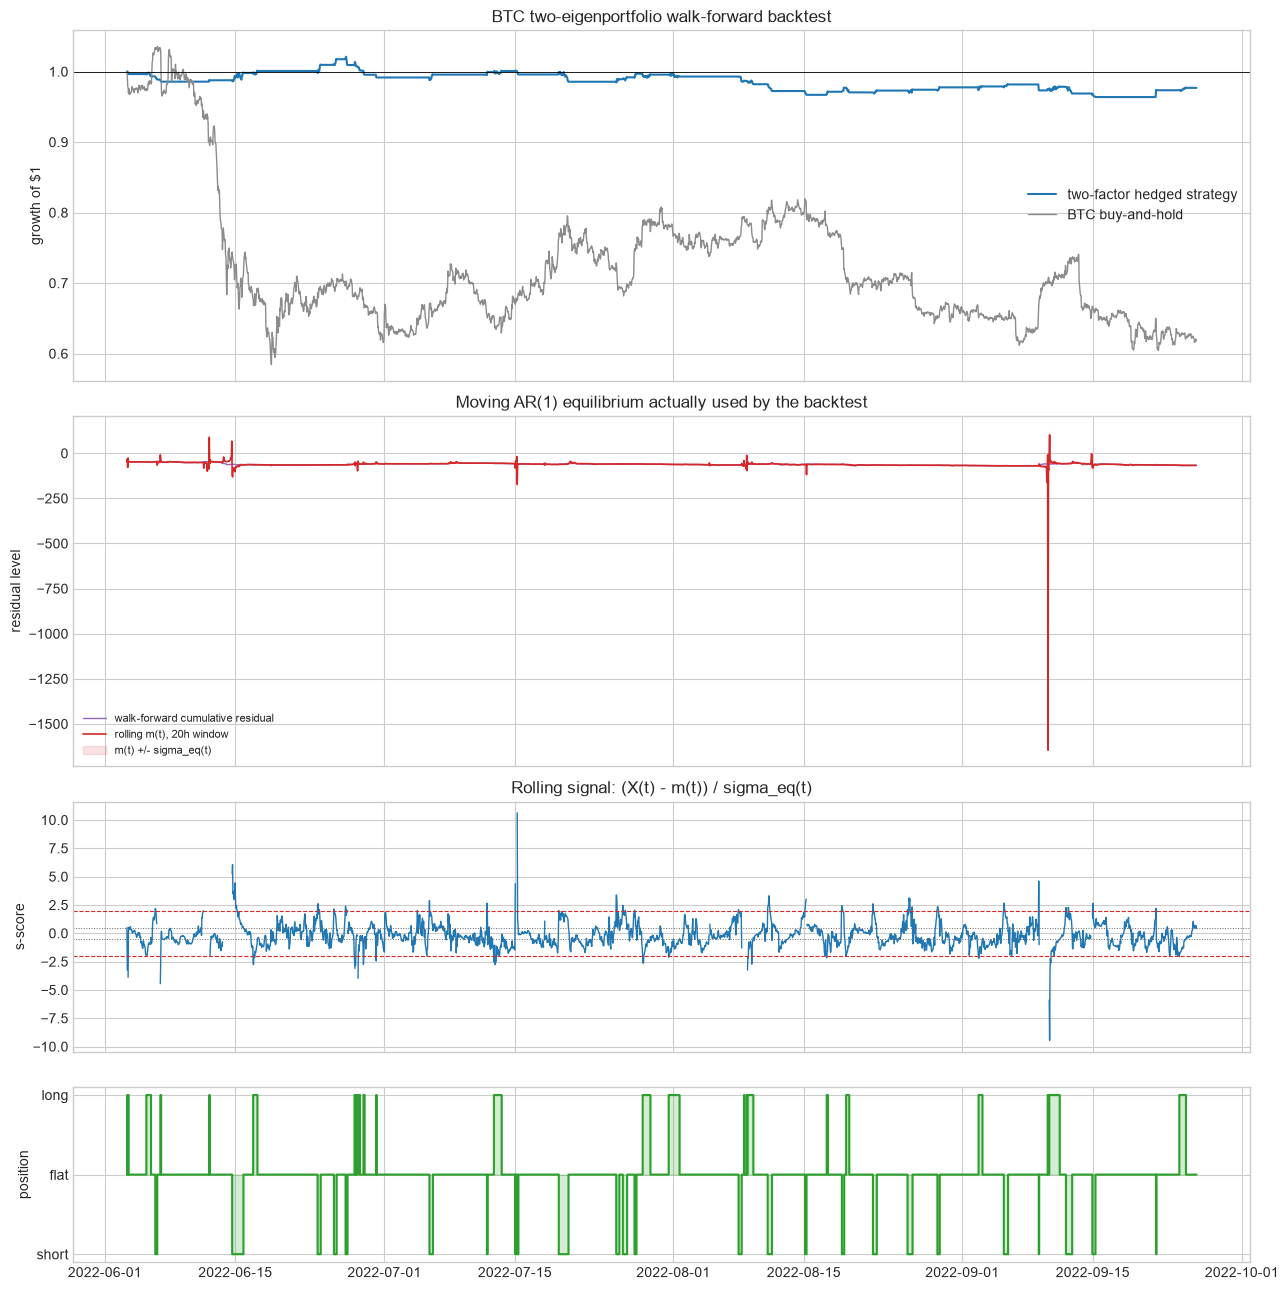

,signal_time,cumulative_residual,moving_m,sigma_eq,s_score,position
startTime,,,,,,
2022-09-25 18:00:00+00:00,2022-09-25 17:00:00+00:00,-66.4983,-67.3810,1.0905,0.8095,0
2022-09-25 19:00:00+00:00,2022-09-25 18:00:00+00:00,-66.3839,-67.4358,1.0028,1.0490,0
2022-09-25 20:00:00+00:00,2022-09-25 19:00:00+00:00,-67.0206,-67.5256,0.9726,0.5193,0
2022-09-25 21:00:00+00:00,2022-09-25 20:00:00+00:00,-67.0722,-67.5197,0.9851,0.4543,0
2022-09-25 22:00:00+00:00,2022-09-25 21:00:00+00:00,-66.8330,-67.4977,0.9603,0.6922,0
2022-09-25 23:00:00+00:00,2022-09-25 22:00:00+00:00,-67.0887,-67.5798,0.8529,0.5758,0
2022-09-26 00:00:00+00:00,2022-09-25 23:00:00+00:00,-67.0815,-67.5784,0.8351,0.5950,0
2022-09-26 01:00:00+00:00,2022-09-26 00:00:00+00:00,-67.1892,-67.5786,0.8498,0.4581,0
2022-09-26 02:00:00+00:00,2022-09-26 01:00:00+00:00,-66.9520,-67.5326,0.8703,0.6672,0


In [ ]:
frame = bt.frame
btc_hold = (1 + frame['token_return']).cumprod()
reconstructed_s = (frame['cumulative_residual'] - frame['moving_m']) / frame['sigma_eq']
assert np.allclose(reconstructed_s, frame['s_score'], equal_nan=True)

fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True, gridspec_kw={'height_ratios': [1.4, 1.4, 1, 0.7]})

axes[0].plot(frame.index, frame['equity'], color='tab:blue', lw=1.5, label='two-factor hedged strategy')
axes[0].plot(frame.index, btc_hold, color='0.55', lw=1.0, label='BTC buy-and-hold')
axes[0].axhline(1, color='black', lw=0.6)
axes[0].set(title='BTC two-eigenportfolio walk-forward backtest', ylabel='growth of $1')
axes[0].legend()

axes[1].plot(frame.index, frame['cumulative_residual'], color='tab:purple', lw=1.0, label='walk-forward cumulative residual')
axes[1].plot(frame.index, frame['moving_m'], color='tab:red', lw=1.2, label=f'rolling m(t), {AR_WINDOW}h window')
axes[1].fill_between(frame.index, frame['moving_lower'], frame['moving_upper'], color='tab:red', alpha=0.13, label='m(t) +/- sigma_eq(t)')
axes[1].set(ylabel='residual level', title='Moving AR(1) equilibrium actually used by the backtest')
axes[1].legend(fontsize=8)

axes[2].plot(frame.index, frame['s_score'], color='tab:blue', lw=1.0)
for level in (-SELECTED_ENTRY, SELECTED_ENTRY): axes[2].axhline(level, color='tab:red', ls='--', lw=0.8)
for level in (-SELECTED_EXIT, SELECTED_EXIT): axes[2].axhline(level, color='0.4', ls=':', lw=0.7)
axes[2].set(ylabel='s-score', title='Rolling signal: (X(t) - m(t)) / sigma_eq(t)')

axes[3].step(frame.index, frame['position'], where='post', color='tab:green')
axes[3].fill_between(frame.index, 0, frame['position'], step='post', alpha=0.2, color='tab:green')
axes[3].set(yticks=[-1, 0, 1], yticklabels=['short', 'flat', 'long'], ylabel='position')
plt.tight_layout(); plt.show()
display(frame[['signal_time', 'cumulative_residual', 'moving_m', 'sigma_eq', 's_score', 'position']].tail(10))

### Interpretation

This is a short diagnostic sample, not evidence of production performance. The key safeguards are consistent use of exactly two factors, one-step residual construction, next-bar execution, a factor-hedged traded spread, and explicit turnover costs.